# 03 — Phase Portraits and Hamiltonian Structure

Visualise the 2D phase space of the acceleration system. Compare Duffing vs Bessel in monostable, weakly bistable, and strongly bistable regimes.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from steering.params import ModelParams, ForcingParams
from steering.models import (
    DuffingModel,
    BesselSteeringModel,
    ContinuousPFLModel,
    DiscretePFLModel,
    FullCircuitModel,
)
from steering.dynamics import VelocityDynamics, AccelerationDynamics
from steering.integrator import Simulation
from steering.visualization.style import use_paper_style

use_paper_style()


In [2]:
from steering.visualization.phase_portrait import plot_phase_portrait
from steering.analysis.fixed_points import find_fixed_points_2d

params_sets = [
    ('monostable',  ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.0)),
    ('weak bistable', ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.36)),
    ('strong bistable', ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.55)),
]


## Print c1, c3, theta_max for each regime

In [3]:
bessel = BesselSteeringModel()
for name, p in params_sets:
    c1, c3 = bessel.taylor_coefficients(p)
    tmax = np.sqrt(2 * c1 / abs(c3)) if (c1 > 0 and c3 < 0) else float('nan')
    print(f'{name:<18}: c1={c1:+.3f}  c3={c3:+.3f}  theta_max={tmax:.3f}')


monostable        : c1=-104.729  c3=+11.985  theta_max=nan
weak bistable     : c1=+10.021  c3=-30.127  theta_max=0.816
strong bistable   : c1=+63.246  c3=-46.411  theta_max=1.651


## Phase portraits: Duffing vs Bessel, undamped

Hamiltonian level sets in light blue; saddle separatrices in black; fixed points marked.

In [6]:
params_sets

[('monostable',
  ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.0, Delta_pop=1.1780972450961724, S=1.0, A=1.0, W_D3=0.0, Delta_pop_pfl2=3.141592653589793, N_neurons=None, nonlinearity='quadratic', nonlinearity_params={}, nonlinearity_pfl2=None)),
 ('weak bistable',
  ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.36, Delta_pop=1.1780972450961724, S=1.0, A=1.0, W_D3=0.0, Delta_pop_pfl2=3.141592653589793, N_neurons=None, nonlinearity='quadratic', nonlinearity_params={}, nonlinearity_pfl2=None)),
 ('strong bistable',
  ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.55, Delta_pop=1.1780972450961724, S=1.0, A=1.0, W_D3=0.0, Delta_pop_pfl2=3.141592653589793, N_neurons=None, nonlinearity='quadratic', nonlinearity_params={}, nonlinearity_pfl2=None))]

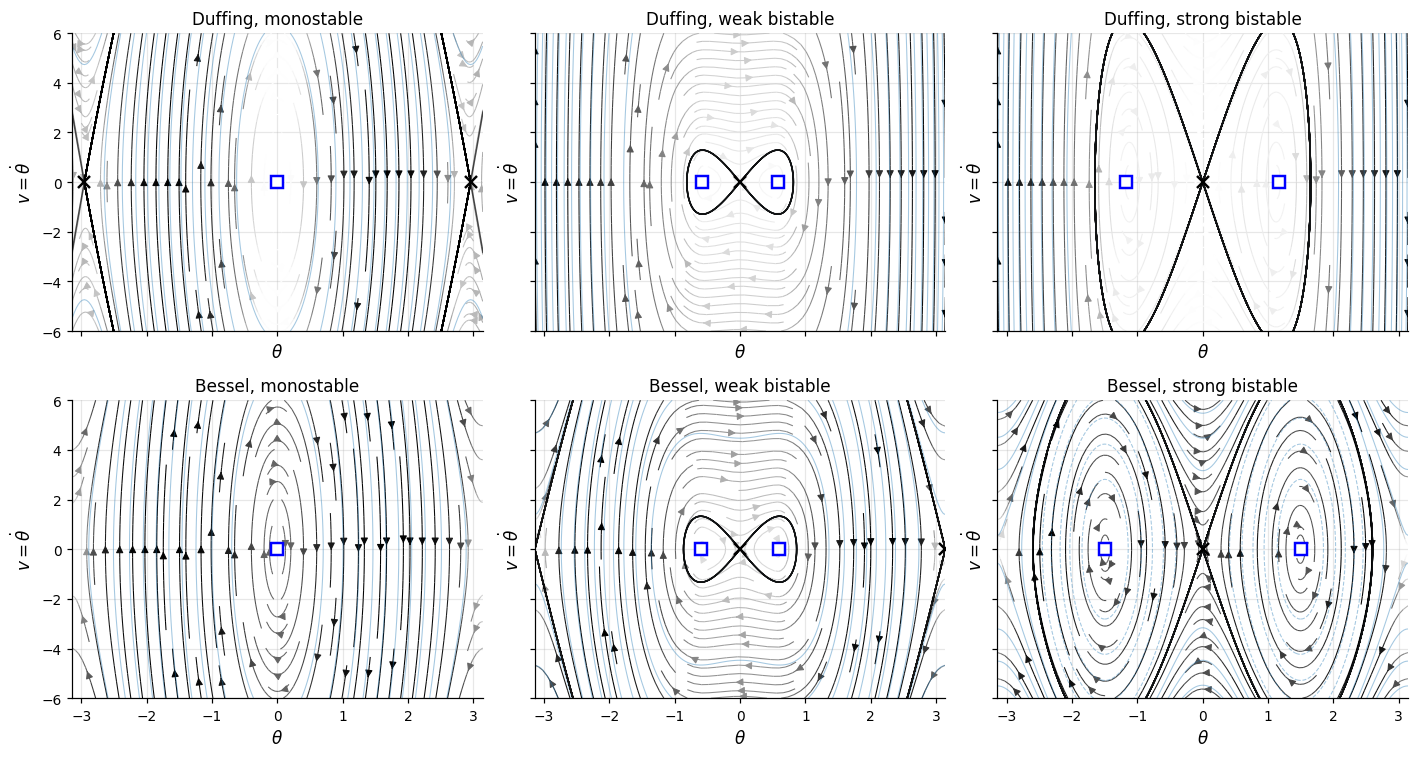

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for j, (name, p) in enumerate(params_sets):
    duff = DuffingModel.from_params(p)
    for i, (label, model) in enumerate([('Duffing', duff), ('Bessel', bessel)]):
        dyn = AccelerationDynamics(model=model, gamma=0.0, topology='planar')
        plot_phase_portrait(
            dyn, p, theta_range=(-np.pi, np.pi), v_range=(-6, 6),
            n_grid=18, n_contours=12, ax=axes[i, j],
        )
        axes[i, j].set_title(f'{label}, {name}')
fig.tight_layout(); plt.show()


## Damped trajectories

Add $\gamma = 0.1$ and overlay several initial-condition trajectories — they spiral into the stable foci.

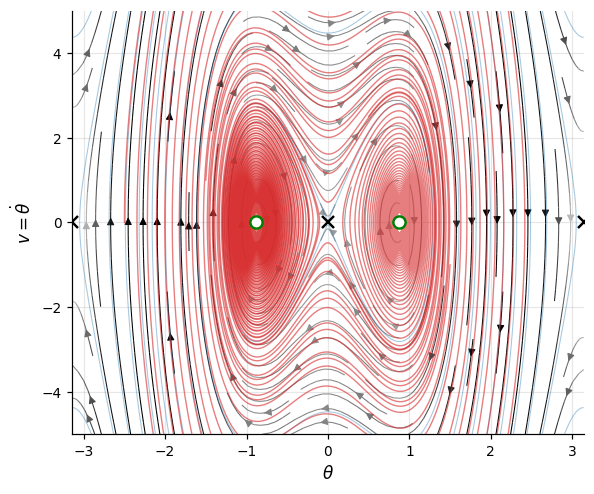

In [5]:
p = ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.4)
dyn = AccelerationDynamics(model=bessel, gamma=0.1)
sim = Simulation(dyn, p)
fig, ax = plt.subplots(figsize=(6, 5))
plot_phase_portrait(dyn, p, theta_range=(-np.pi, np.pi),
                    v_range=(-5, 5), n_grid=18, n_contours=10,
                    overlay_separatrix=False, ax=ax)
for ic in [(-1.5, 1.0), (1.5, -1.0), (-2.5, 0.0), (0.5, 2.5)]:
    res = sim.run(np.array(ic), (0.0, 60.0))
    ax.plot(res.states[:, 0], res.states[:, 1], 'C3-', lw=0.9, alpha=0.6)
ax.set_xlim(-np.pi, np.pi); ax.set_ylim(-5, 5)
plt.show()
